In [1]:
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import seaborn as sns
import torch
from emle.models import EMLE
from emle.train import EMLETrainer
from emle.train._utils import pad_to_max
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

color_by_z = {1: "grey", 6: "cyan", 7: "blue", 8: "red", 16: "yellow"}
ANGSTROM_TO_BOHR = 1.8897259886
HARTREE_TO_KJ_MOL = 2625.5002

/home/joaomorado/micromamba/envs/fes-ml-aev/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

### Load Data

In [3]:
xdm_data = h5py.File("pyxdm.output.h5", "r")

# Load exchange-hole moments
m1 = xdm_data["summary_moments"][:, :, 0]
m2 = xdm_data["summary_moments"][:, :, 1]
m3 = xdm_data["summary_moments"][:, :, 2]

m1_ds = pad_to_max(m1).to(device=device, dtype=dtype)
m2_ds = pad_to_max(m2).to(device=device, dtype=dtype)
m3_ds = pad_to_max(m3).to(device=device, dtype=dtype)

# Load atomic data
xyz = xdm_data["atoms"][:, :, 1:4] / ANGSTROM_TO_BOHR
species = xdm_data["atoms"][:, :, 0]

# Pad to max number of atoms
xyz_ds = pad_to_max(xyz).to(device=device, dtype=dtype)
species_ds = pad_to_max(species).to(device=device, dtype=torch.long)
dummy_s = torch.zeros(xyz_ds.shape[0], xyz_ds.shape[1], 1).to(
    device=device, dtype=dtype
)
q_mol = torch.zeros(xyz_ds.shape[0]).to(device=device, dtype=dtype)

### Generate effective exchange-hole dipole moments

In [4]:
def c6(alpha, m1):
    """XDM C6 coefficient calculation for homoatomic case."""
    return alpha * m1 / 2.0


def c8(alpha, m2):
    """XDM C8 coefficient calculation for homoatomic case."""
    return alpha * m2 * 3 / 2.0


def c10(alpha, m1, m2, m3):
    """XDM C10 coefficient calculation for homoatomic case."""
    return 2.0 * alpha * m3 + 21 / 10 * alpha * m2**2 / (m1 + 1e-16)

In [5]:
emle = EMLE(
    model="../../emle_models/ligand_patched_species_iter2.mat",
    alpha_mode="species",
    device=device,
)
emle_base = emle._emle_base
s, q_core, q_val, A_thole, _, alpha_unscreened, *_ = emle_base(
    species_ds, xyz_ds, q_mol
)
s = s.detach()
q_core = q_core.detach()
q_val = q_val.detach()
A_thole = A_thole.detach()
alpha = emle_base.get_isotropic_polarizabilities_thole(A_thole)
alpha = alpha.detach() * (species_ds > 0)
rmin2 = 2.54 * alpha ** (1 / 7) * 2

In [6]:
# Calculate dispersion coefficients
c6_train = c6(alpha, m1_ds)
c8_train = c8(alpha, m2_ds)
c10_train = c10(alpha, m1_ds, m2_ds, m3_ds)

# Setup grid
n = 1000
r_start = 1.20
rij_scale = torch.linspace(r_start, 3.0, n).to(device=device)
rmin_expanded = rmin2.unsqueeze(-1)
rij = rmin_expanded * rij_scale

# Calculate dispersion energy
Eij = -(
    c6_train[..., None] / (rij**6 + 1e-16)
    + c8_train[..., None] / (rij**8 + 1e-16)
    + c10_train[..., None] / (rij**10 + 1e-16)
)

In [7]:
# Setup optimization
lr = 0.1
m1_eff = torch.nn.Parameter(m1_ds.clone().detach())
optimizer = torch.optim.Adam([m1_eff], lr=lr)

# Perform optimization
n_epochs = 1000
mask = species_ds > 0
for epoch in range(n_epochs):
    optimizer.zero_grad()
    c6_opt = c6(alpha, m1_eff).abs()
    Eij_opt = -c6_opt[..., None] / (rij**6 + 1e-16)
    delta = Eij_opt - Eij
    loss = torch.mean(delta[mask] ** 2) / torch.var(Eij[mask])
    loss.backward(retain_graph=True)
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.1957002431154251
Epoch 50, Loss: 0.011851197108626366


Epoch 100, Loss: 0.00760692497715354
Epoch 150, Loss: 0.0071828486397862434
Epoch 200, Loss: 0.007164851762354374
Epoch 250, Loss: 0.007164590060710907
Epoch 300, Loss: 0.007164590060710907
Epoch 350, Loss: 0.007164590060710907
Epoch 400, Loss: 0.00716458959504962
Epoch 450, Loss: 0.007164590060710907
Epoch 500, Loss: 0.007164590060710907
Epoch 550, Loss: 0.007164590060710907
Epoch 600, Loss: 0.00716458959504962
Epoch 650, Loss: 0.007164590060710907
Epoch 700, Loss: 0.007164590060710907
Epoch 750, Loss: 0.00716458959504962
Epoch 800, Loss: 0.007164590060710907
Epoch 850, Loss: 0.007164590060710907
Epoch 900, Loss: 0.007164590060710907
Epoch 950, Loss: 0.007164590060710907


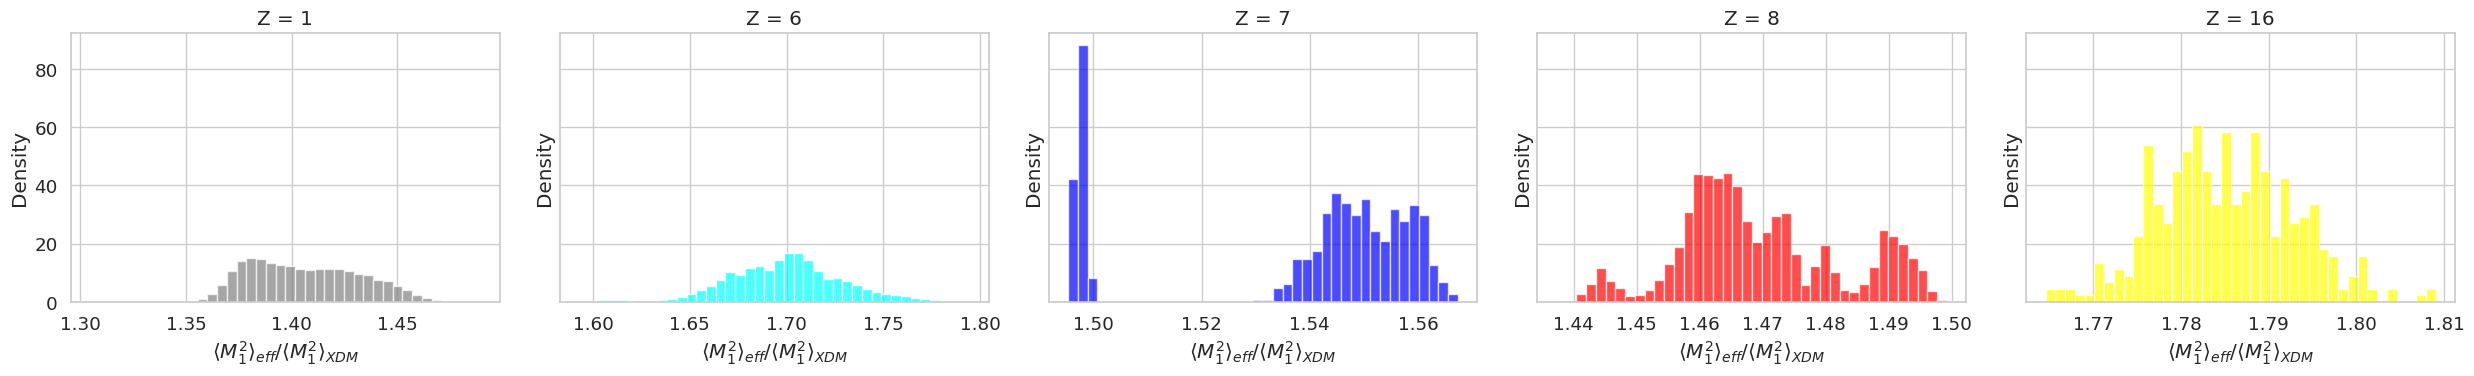

In [8]:
# Compute ratios
c6_optimized = c6(alpha, m1_eff).detach().cpu().numpy().flatten()
c6_orig = c6_train.cpu().numpy().flatten()
ratios = c6_optimized / c6_orig
species_np = species_ds.cpu().numpy().flatten()

sns.set(style="whitegrid", font_scale=1.2)

# Create one subplot per Z
z_values = sorted(color_by_z.keys())
fig, axes = plt.subplots(1, len(z_values), figsize=(5 * len(z_values), 4), sharey=True)

# If only one Z, axes may not be iterable
if len(z_values) == 1:
    axes = [axes]

for ax, z in zip(axes, z_values):
    mask = species_np == z
    ax.hist(
        ratios[mask],
        bins=40,
        alpha=0.7,
        color=color_by_z[z],
        density=True,
    )
    ax.set_title(f"Z = {z}")
    ax.set_xlabel(r"$\langle M_1^2 \rangle_{eff}  / \langle M_1^2 \rangle_{XDM}$")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

### Create training dataset

In [9]:
perm = torch.randperm(xyz_ds.shape[0])
n_samples = len(perm)
n_train = int(0.8 * n_samples)
train_idx = perm[:n_train]
val_idx = perm[n_train:]


def split_tensor(t, idx_train, idx_val):
    return t[idx_train], t[idx_val]


xyz_train, xyz_val = split_tensor(xyz_ds, train_idx, val_idx)
species_train, species_val = split_tensor(species_ds, train_idx, val_idx)
m1_train, m1_val = split_tensor(m1_eff.detach(), train_idx, val_idx)
dummy_s_train, dummy_s_val = split_tensor(dummy_s, train_idx, val_idx)

In [10]:
species = scipy.io.loadmat("../../emle_models/ligand_patched_species_iter2.mat")
reference = scipy.io.loadmat("../../emle_models/ligand_patched_reference_iter2.mat")

### Train <M1> coefficients

In [11]:
plot_data_filename = "c6_training_data_results.mat"
trainer = EMLETrainer()
trainer.train(
    z=species_train,
    xyz=xyz_train,
    s=dummy_s_train,
    c6=m1_train,
    q_mol=torch.zeros(xyz_train.shape[0]),
    lr_c6=1e-2,
    epochs=1500,
    emle_model="../../emle_models/ligand_patched_species_iter2.mat",
    plot_data_filename=plot_data_filename,
    model_filename=f"ligand_patched_species_iter2_c6_{r_start}.mat",
    l2_reg_c6=1e-3,
    alpha_mode="species",
)

2025-12-19 16:02:39.132 | INFO     | emle.train._trainer:train:625 - Loading pre-trained EMLE model from '../../emle_models/ligand_patched_species_iter2.mat'
2025-12-19 16:02:39.144 | INFO     | emle.train._trainer:train:695 - Fitting c6 values...


2025-12-19 16:02:40.092 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 10: Loss =  23.6544    RMSE =   4.8636    Max Error =  19.7825
2025-12-19 16:02:40.988 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 20: Loss =  20.7168    RMSE =   4.5516    Max Error =  19.8892
2025-12-19 16:02:41.856 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 30: Loss =  17.3565    RMSE =   4.1661    Max Error =  20.0191
2025-12-19 16:02:42.728 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 40: Loss =  13.8095    RMSE =   3.7161    Max Error =  20.1654
2025-12-19 16:02:43.599 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 50: Loss =  10.4676    RMSE =   3.2353    Max Error =  20.3167
2025-12-19 16:02:44.470 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 60: Loss =   7.7323    RMSE =   2.7807    Max Error =  20.4580
2025-12-19 16:02:45.342 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 70: Loss =   5.6941    RMSE =   2.3862    Max Error =  

EMLEBase(
  (_emle_aev_computer): EMLEAEVComputer(
    (_aev_computer): AEVComputer()
  )
)

### Plot results for training dataset

In [12]:
# Get training results
training_results = scipy.io.loadmat(plot_data_filename)

# Get testing results
emle = EMLE(
    model=f"ligand_patched_species_iter2_c6_{r_start}.mat",
    dispersion_mode="c6",
    device=device,
)
emle_base = emle._emle_base
a, b, c, d, c6_pred_val, *_ = emle_base.forward(
    species_val,
    xyz_val.to(torch.float32),
    torch.zeros(xyz_val.shape[0], device=device),
    calc_A_thole=True,
    calc_c6=True,
)

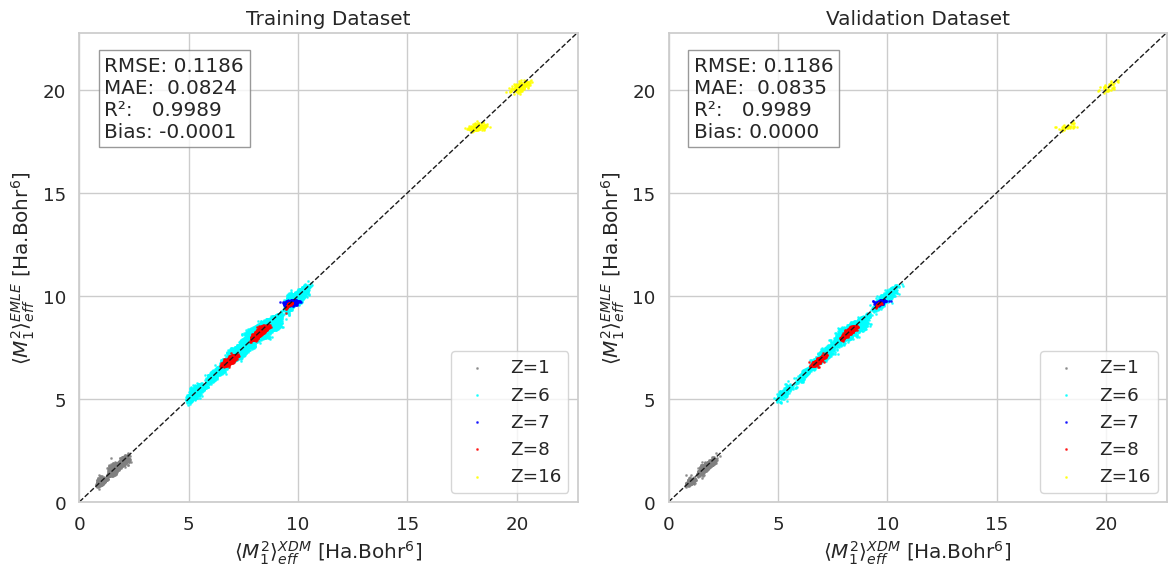

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set(style="whitegrid", font_scale=1.2)
xlabel = r"$\langle M_1^2 \rangle_{eff}^{XDM}$ [Ha.Bohr$^6$]"
ylabel = r"$\langle M_1^2 \rangle_{eff}^{EMLE}$ [Ha.Bohr$^6$]"

datasets = [
    {
        "ax": axes[0],
        "y_true": training_results["c6_qm"],
        "y_pred": training_results["c6_emle"],
        "species": species_train.cpu().numpy(),
        "title": "Training Dataset",
    },
    {
        "ax": axes[1],
        "y_true": m1_val.cpu().detach().numpy(),
        "y_pred": c6_pred_val.cpu().detach().numpy(),
        "species": species_val.cpu().numpy(),
        "title": "Validation Dataset",
    },
]

for data in datasets:
    ax = data["ax"]
    species = data["species"]
    y_true = data["y_true"]
    y_pred = data["y_pred"]

    # Calculate error and correlation metrics
    mask_global = y_true > 0
    rmse = np.sqrt(mean_squared_error(y_true[mask_global], y_pred[mask_global]))
    mae = mean_absolute_error(y_true[mask_global], y_pred[mask_global])
    r2 = r2_score(y_true[mask_global], y_pred[mask_global])
    bias = np.mean(y_pred[mask_global] - y_true[mask_global])

    for z in color_by_z.keys():
        mask = (species == z) & (y_true > 0)
        ax.scatter(
            y_true[mask],
            y_pred[mask],
            alpha=0.7,
            s=1,
            color=color_by_z[z],
            label=f"Z={z}",
        )

    lims = [0, training_results["c6_qm"][training_results["c6_qm"] > 0].max() * 1.1]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(data["title"])

    text_metrics = (
        f"RMSE: {rmse:.4f}\nMAE:  {mae:.4f}\nR²:   {r2:.4f}\nBias: {bias:.4f}"
    )
    ax.text(
        0.05,
        0.95,
        text_metrics,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

    ax.legend()

plt.tight_layout()
plt.show()

### Mapping to OpenFF atom types

In [14]:
import pickle as pkl
import re

from openff.toolkit import ForceField
from openff.units import unit as off_unit
from openmm import unit


def natural_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]

In [15]:
# Load atom types
atom_types = pkl.load(open("atom_types.pkl", "rb"))

# Get OpenFF vdW parameters
force_field = ForceField("openff-2.0.0.offxml")
vdw_handler = force_field.get_parameter_handler("vdW")
off_vdw_params = {
    param.id: {
        "sigma": param.sigma.to_openmm().value_in_unit(unit.nanometer),
        "epsilon": param.epsilon.to_openmm().value_in_unit(unit.kilojoule_per_mole),
        "smirks": param.smirks,
    }
    for param in vdw_handler.parameters
}

In [16]:
# Get <M_1^2>eff for the complete dataset
emle = EMLE(
    model=f"ligand_patched_species_iter2_c6_{r_start}.mat",
    dispersion_mode="c6",
    device=device,
)
emle_base = emle._emle_base
a, b, c, d, c6_pred_val, *_ = emle_base.forward(
    species_ds,
    xyz_ds.to(torch.float32),
    torch.zeros(xyz_ds.shape[0], device=device),
    calc_A_thole=True,
    calc_c6=True,
)
# Convert to LJ parameters
c6 = 0.5 * c6_pred_val * alpha
rmin = 2 * (2.54 * alpha ** (1 / 7))
# rmin = rmin2_ref[species_ds] * vol_ratio**(1/3) * 2
sigma = rmin / (2 ** (1 / 6))
epsilon = c6 / (4 * sigma**6)

# Convert units
sigma /= ANGSTROM_TO_BOHR * 10
epsilon *= HARTREE_TO_KJ_MOL

In [17]:
# Map from predicted LJ parameters to OpenFF vdW parameters
emle_lj = {param_id: {"sigma": [], "epsilon": []} for param_id in off_vdw_params.keys()}
for i, mol in enumerate(atom_types):
    for j, at in enumerate(mol):
        emle_lj[at]["sigma"].append(sigma[i][j].item())
        emle_lj[at]["epsilon"].append(epsilon[i][j].item())

# Discard empty entries
emle_lj = {k: v for k, v in emle_lj.items() if v["sigma"] and v["epsilon"]}

# Calculate mean values for each parameter
for param_id, values in emle_lj.items():
    emle_lj[param_id]["sigma_mean"] = np.mean(values["sigma"])
    emle_lj[param_id]["epsilon_mean"] = np.mean(values["epsilon"])
    emle_lj[param_id]["smirks"] = off_vdw_params[param_id]["smirks"]

In [18]:
# Save OpenFF force field
for param in force_field.get_parameter_handler("vdW").parameters:
    if param.id not in emle_lj:
        continue
    param.sigma = emle_lj[param.id]["sigma_mean"] * off_unit.nanometer
    param.epsilon = emle_lj[param.id]["epsilon_mean"] * off_unit.kilojoules_per_mole

force_field.to_file("openff-2.0.0-emle.offxml")

### Plot distributons of XDM-based LJ parameters

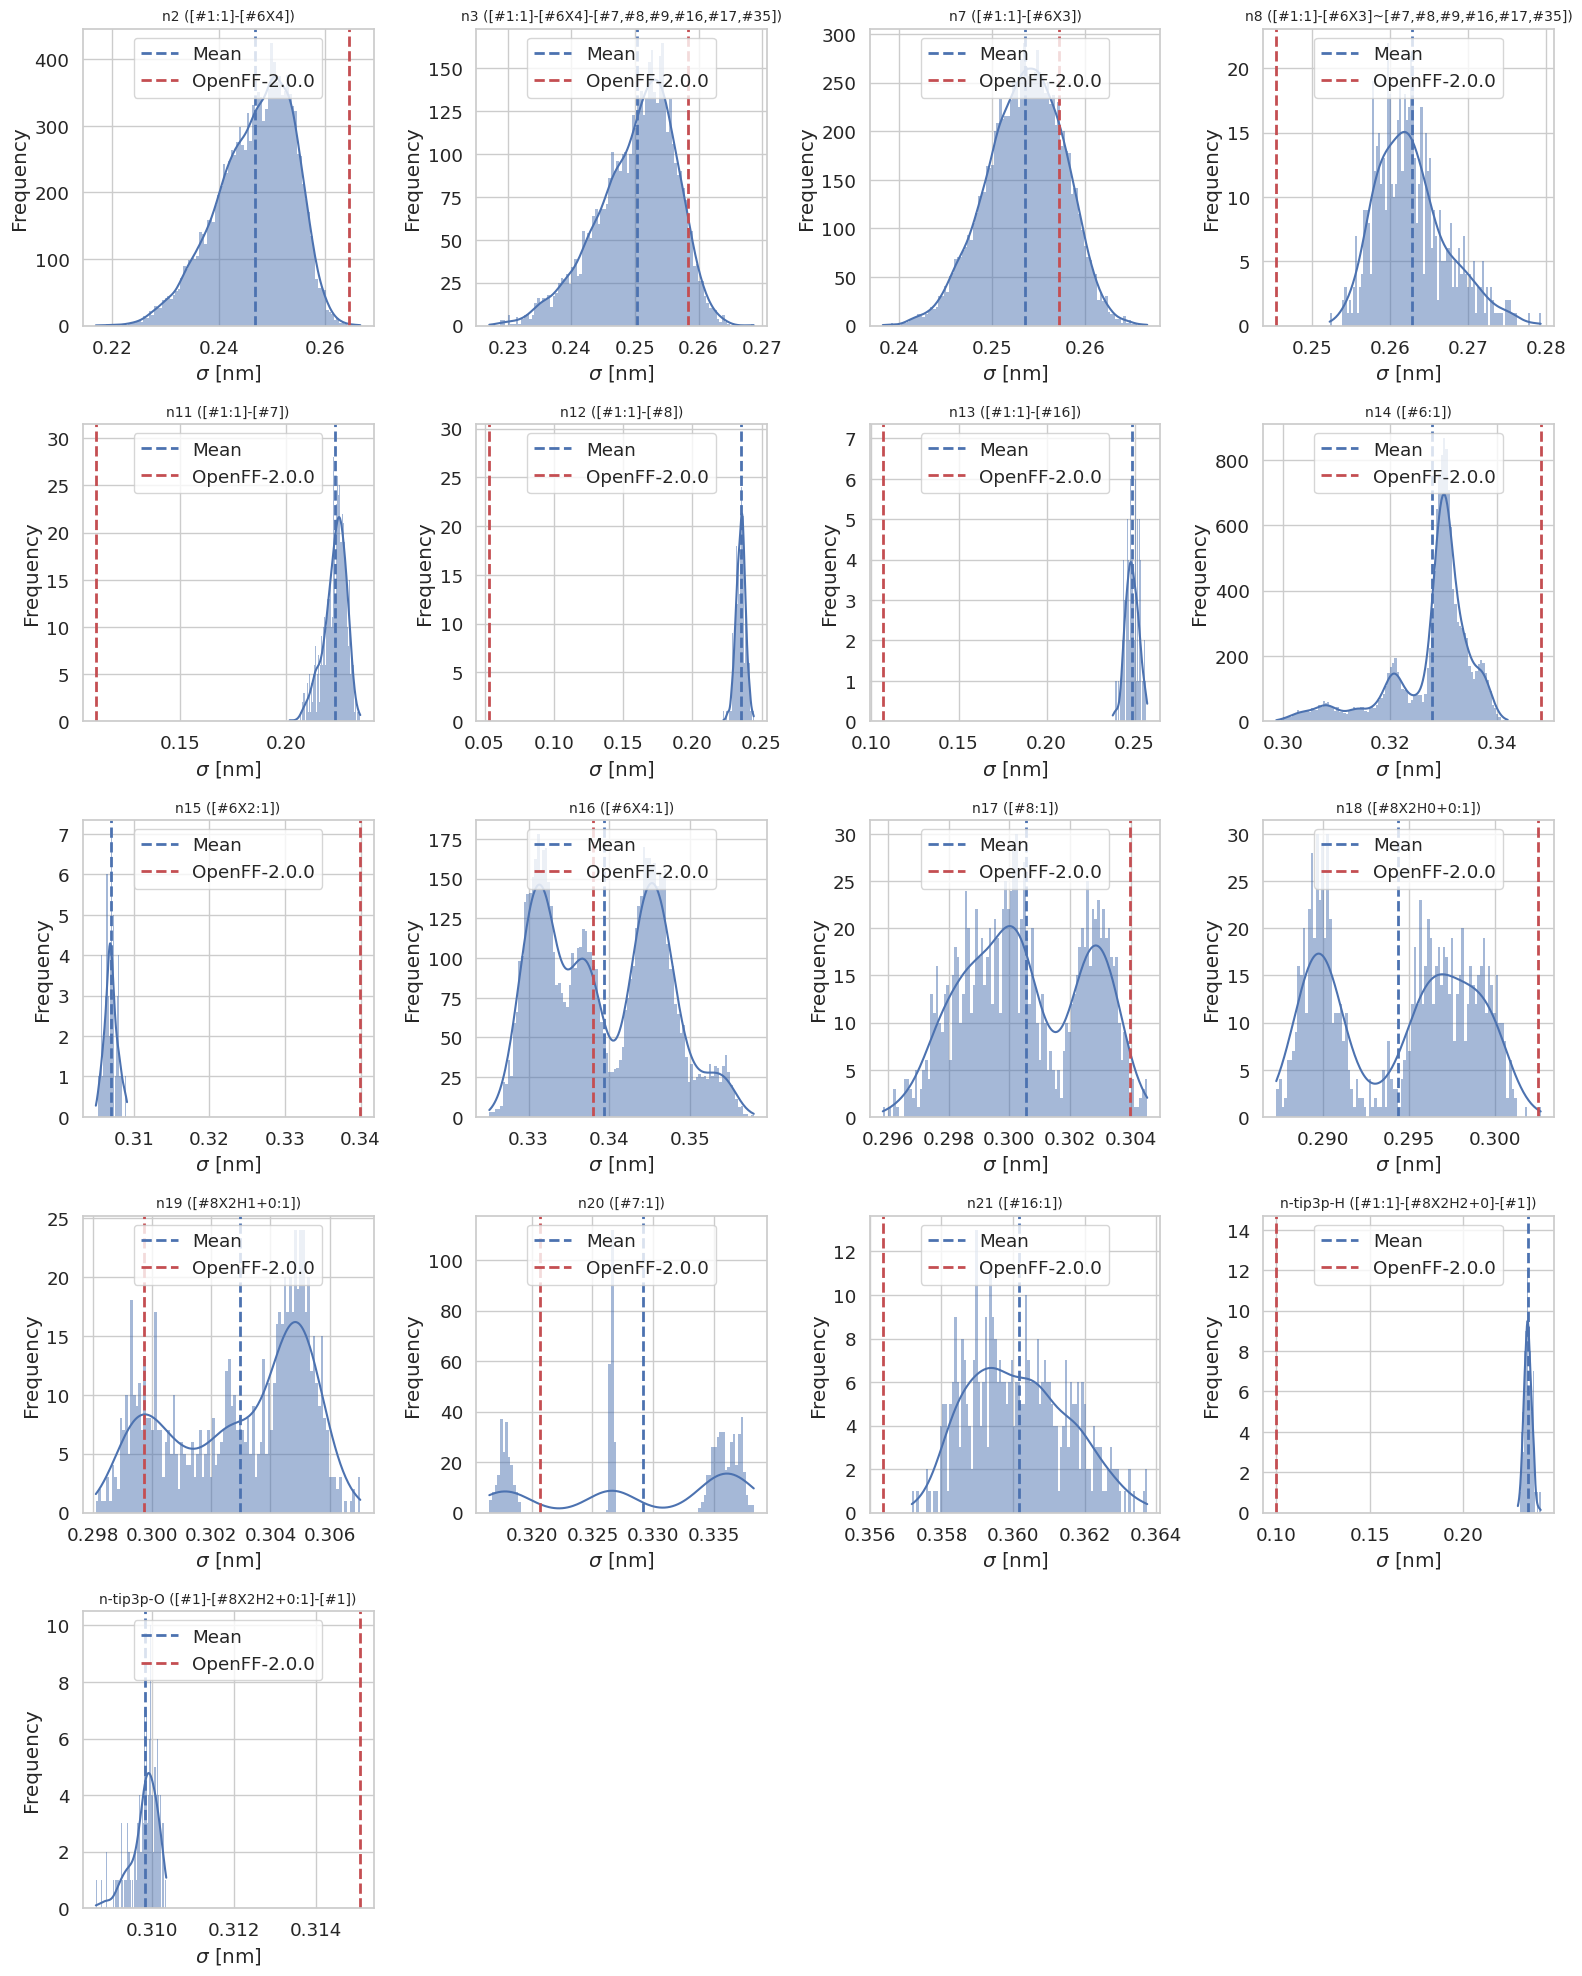

In [19]:
off_types = sorted(emle_lj.keys(), key=natural_key)
n = len(off_types)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, at in zip(axes, off_types):
    data = emle_lj[at]["sigma"]
    mean_val = emle_lj[at]["sigma_mean"]
    off_val = off_vdw_params[at]["sigma"]

    sns.histplot(data, bins=100, kde=True, ax=ax, linewidth=0)
    ax.axvline(mean_val, color="b", linestyle="dashed", linewidth=2, label="Mean")
    ax.axvline(
        off_val, color="r", linestyle="dashed", linewidth=2, label="OpenFF-2.0.0"
    )

    ax.set_title(f"{at} ({emle_lj[at]['smirks']})", fontsize=10)
    ax.set_xlabel(r"$\sigma$ [nm]")
    ax.set_ylabel("Frequency")
    ax.legend(loc="upper center")

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()

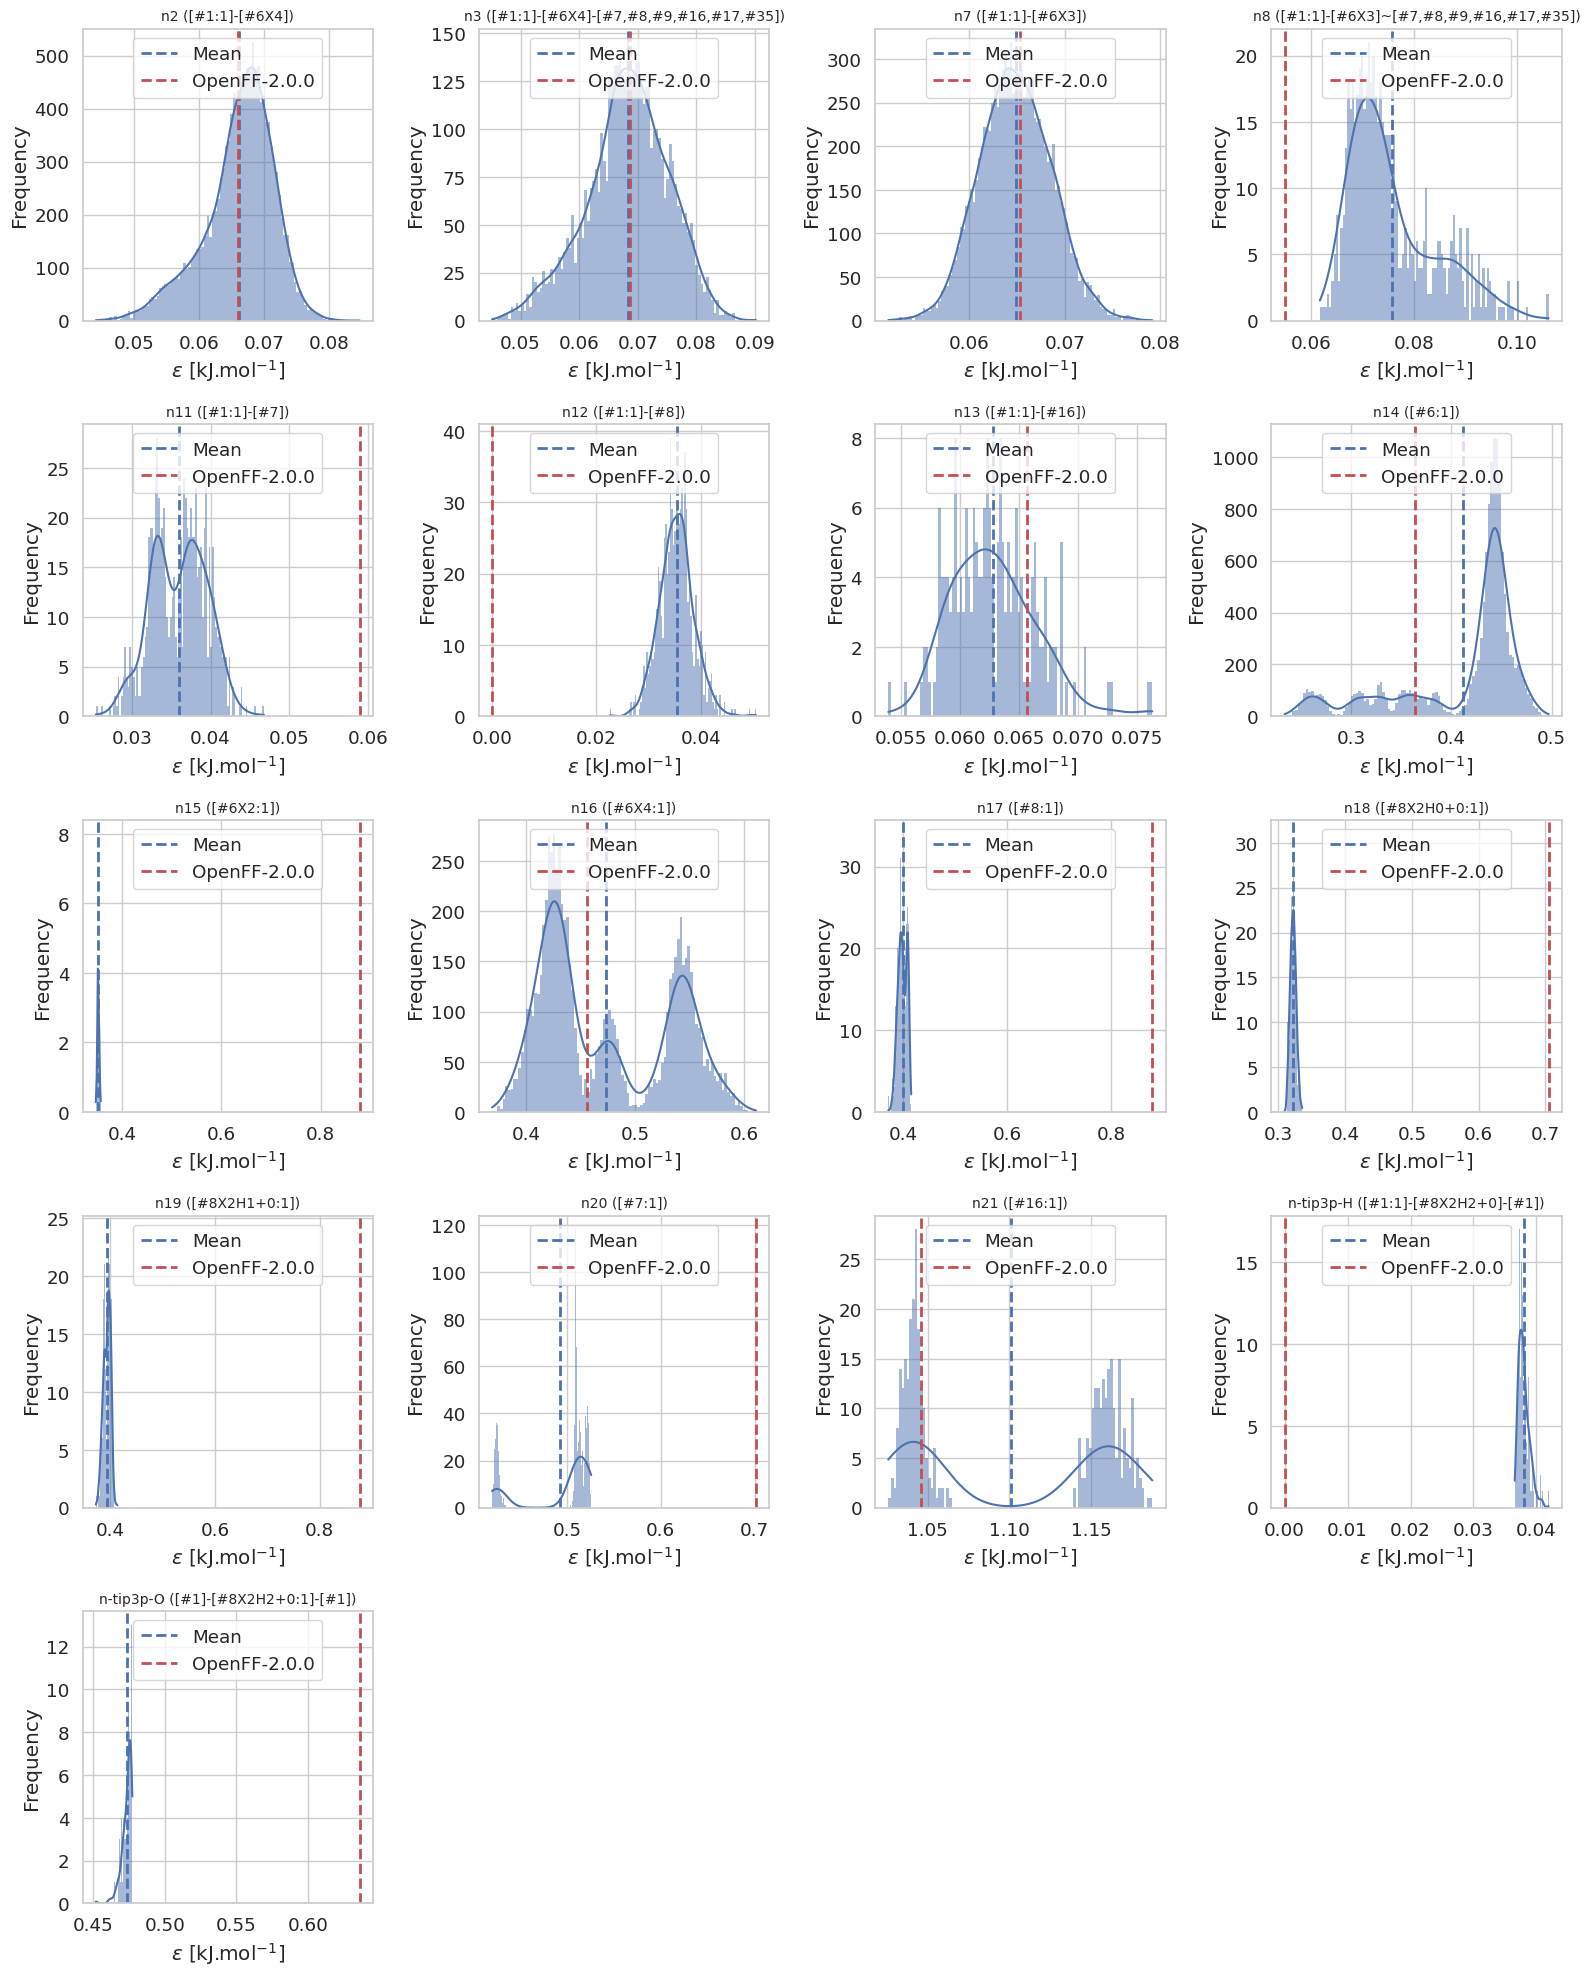

In [20]:
off_types = sorted(emle_lj.keys(), key=natural_key)
n = len(off_types)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, at in zip(axes, off_types):
    data = emle_lj[at]["epsilon"]
    mean_val = emle_lj[at]["epsilon_mean"]
    off_val = off_vdw_params[at]["epsilon"]

    sns.histplot(data, bins=100, kde=True, ax=ax, linewidth=0)
    ax.axvline(mean_val, color="b", linestyle="dashed", linewidth=2, label="Mean")
    ax.axvline(
        off_val, color="r", linestyle="dashed", linewidth=2, label="OpenFF-2.0.0"
    )

    ax.set_title(f"{at} ({emle_lj[at]['smirks']})", fontsize=10)
    ax.set_xlabel(r"$\epsilon$ [kJ.mol$^{-1}$]")
    ax.set_ylabel("Frequency")
    ax.legend(loc="upper center")

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()

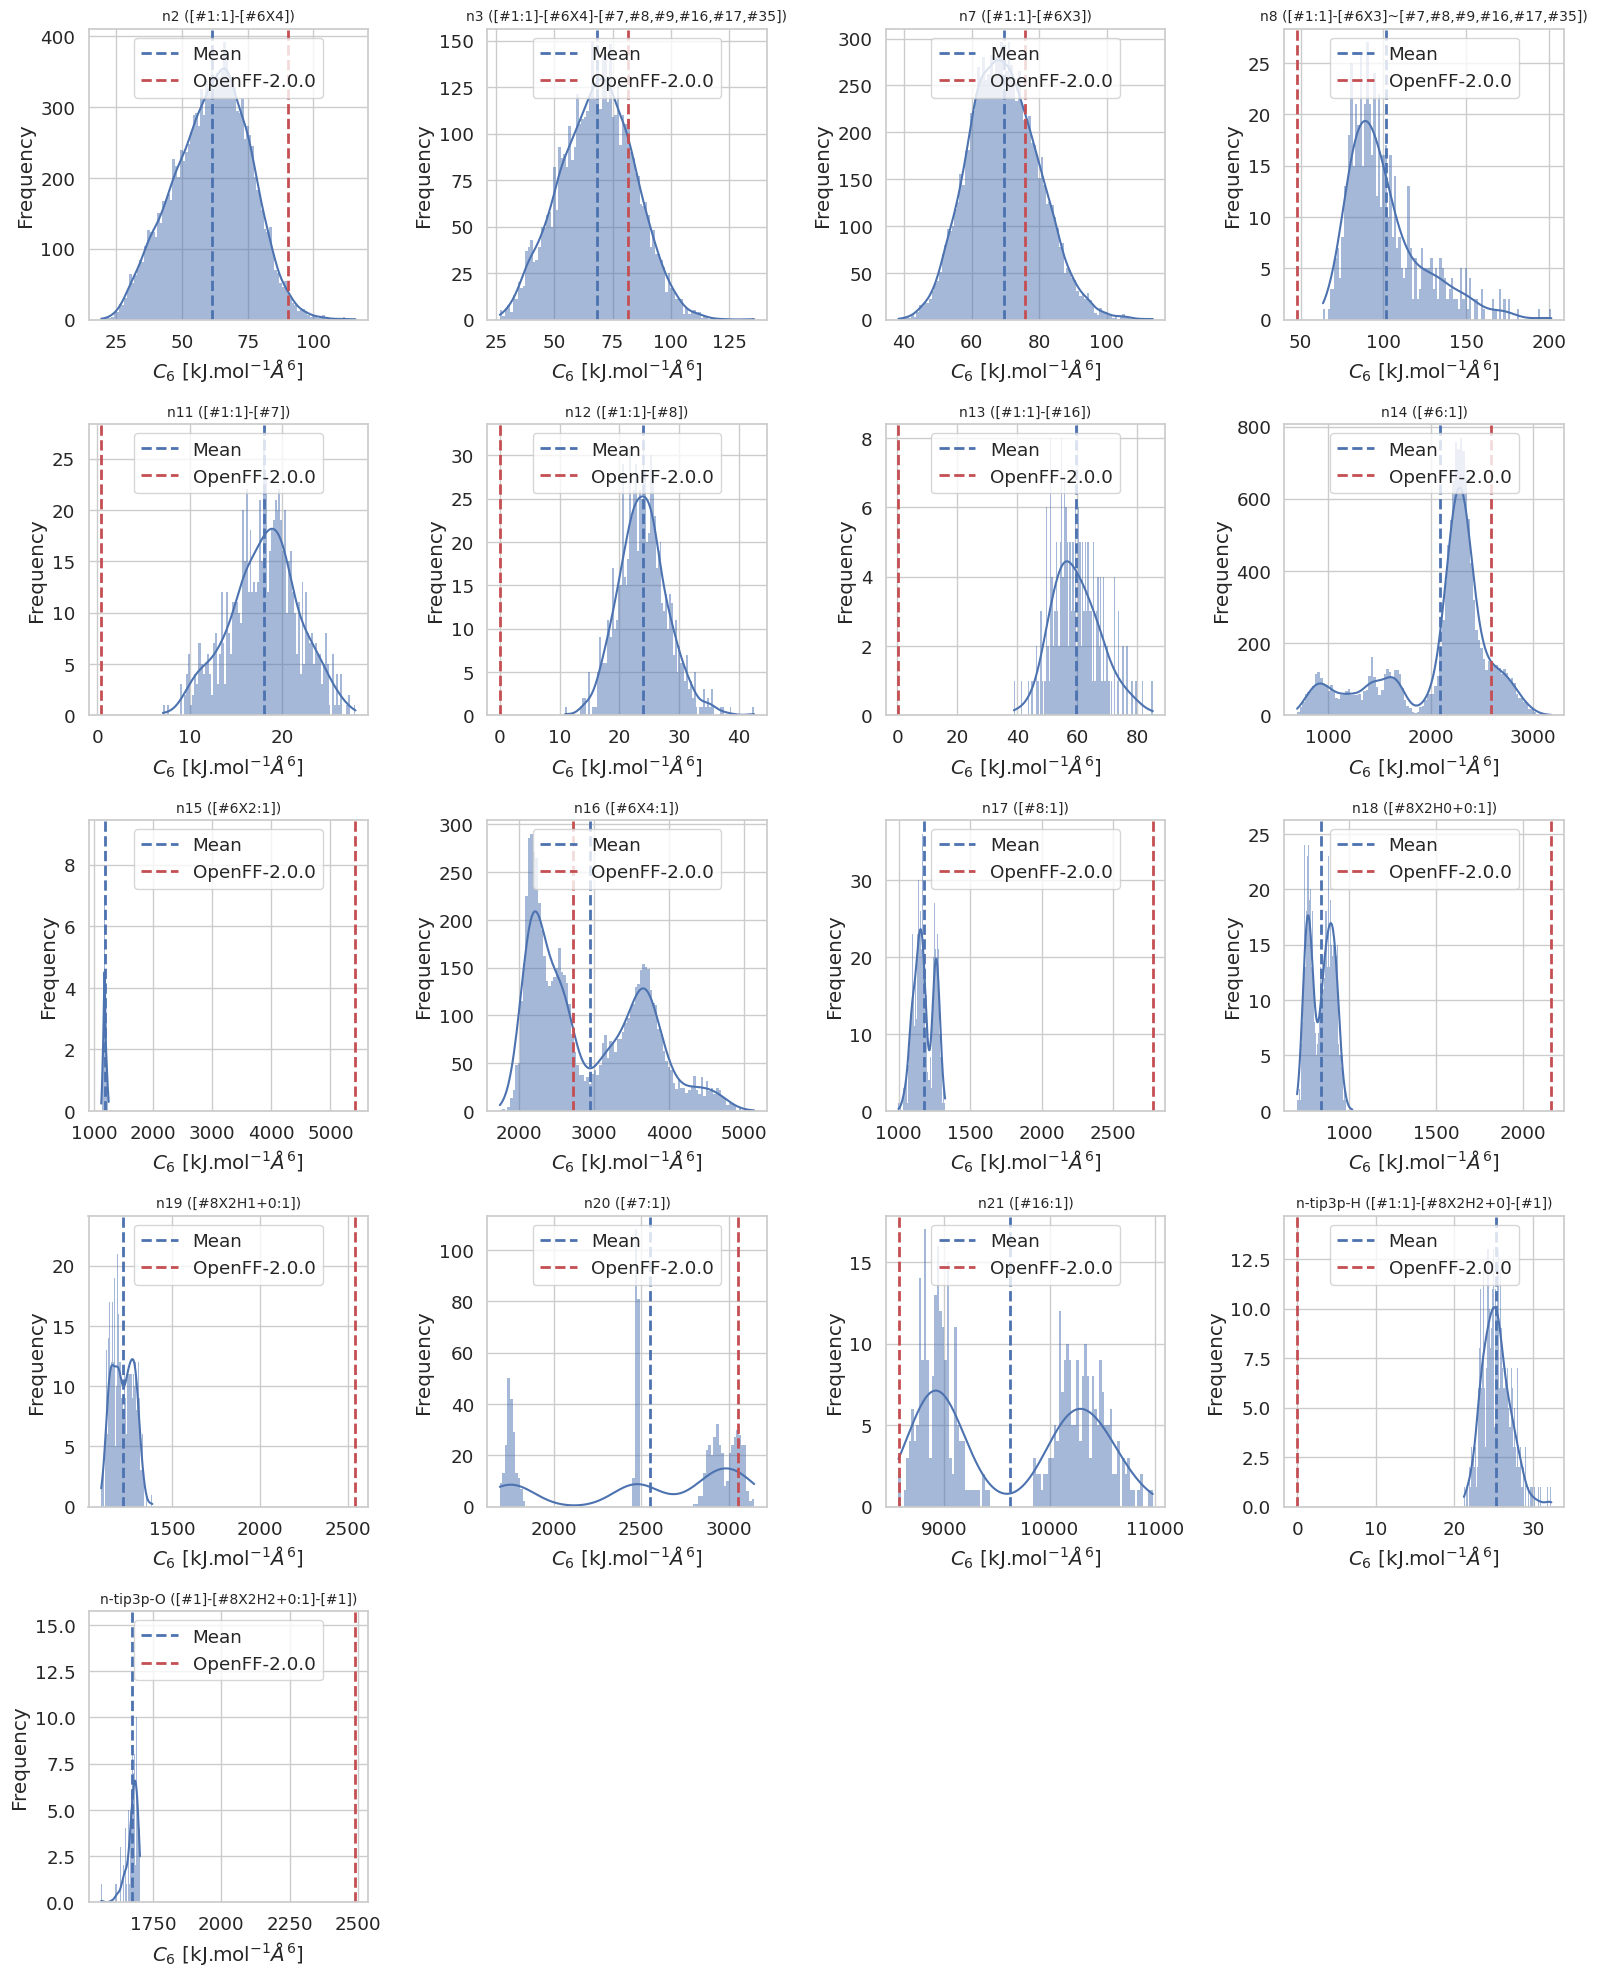

In [21]:
off_types = sorted(emle_lj.keys(), key=natural_key)
n = len(off_types)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, at in zip(axes, off_types):
    data = (
        4
        * np.array(emle_lj[at]["epsilon"])
        * (np.array(emle_lj[at]["sigma"]) * 10) ** 6
    )
    mean_val = data.mean()
    off_val = (
        4
        * np.array(off_vdw_params[at]["epsilon"])
        * (np.array(off_vdw_params[at]["sigma"]) * 10) ** 6
    )

    sns.histplot(data, bins=100, kde=True, ax=ax, linewidth=0)
    ax.axvline(mean_val, color="b", linestyle="dashed", linewidth=2, label="Mean")
    ax.axvline(
        off_val, color="r", linestyle="dashed", linewidth=2, label="OpenFF-2.0.0"
    )

    ax.set_title(f"{at} ({emle_lj[at]['smirks']})", fontsize=10)
    ax.set_xlabel(r"$C_6$ [kJ.mol$^{-1}\AA^{6}$]")
    ax.set_ylabel("Frequency")
    ax.legend(loc="upper center")

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()

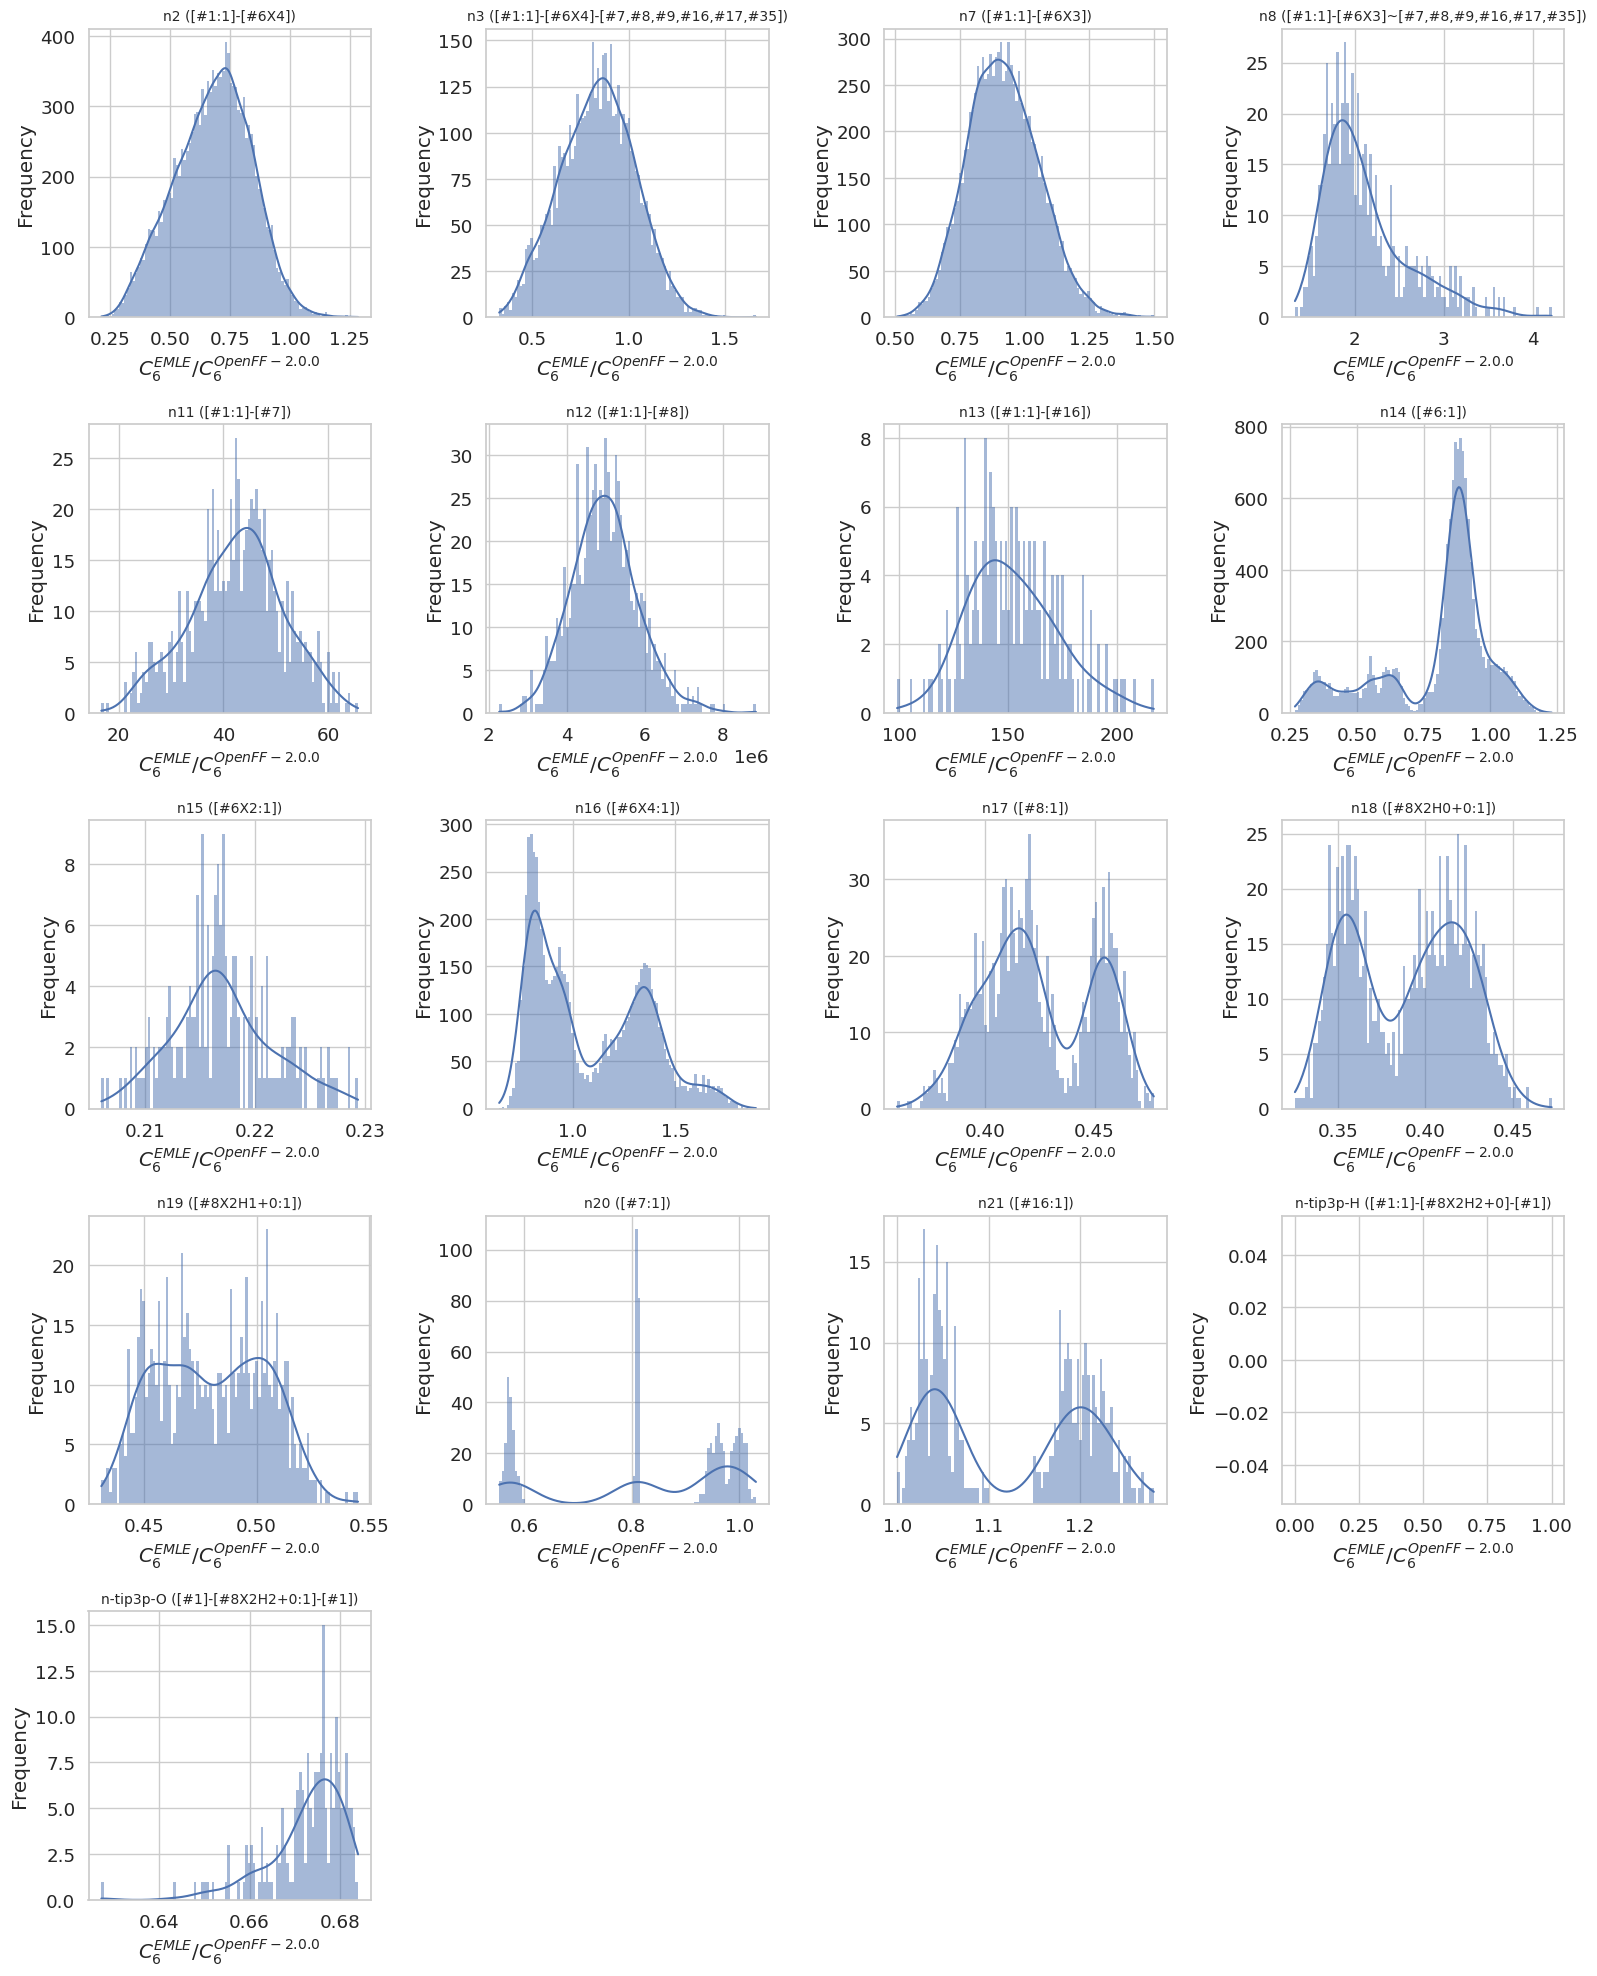

In [22]:
off_types = sorted(emle_lj.keys(), key=natural_key)
n = len(off_types)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, at in zip(axes, off_types):
    data = (
        4
        * np.array(emle_lj[at]["epsilon"])
        * (np.array(emle_lj[at]["sigma"]) * 10) ** 6
    )
    mean_val = data.mean()
    off_val = (
        4
        * np.array(off_vdw_params[at]["epsilon"])
        * (np.array(off_vdw_params[at]["sigma"]) * 10) ** 6
    )

    sns.histplot(data / off_val, bins=100, kde=True, ax=ax, linewidth=0)

    ax.set_title(f"{at} ({emle_lj[at]['smirks']})", fontsize=10)
    ax.set_xlabel(r"$C_6^{EMLE} / C_6^{OpenFF-2.0.0}$")
    ax.set_ylabel("Frequency")

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()

In [23]:
from openff.toolkit import ForceField, Molecule, Topology
from openff.units import unit

ff = ForceField("openff-2.0.0.offxml")
mol = Molecule.from_smiles("C1CCCCC1")
mol.generate_conformers(n_conformers=1)
topology_off = Topology.from_molecules([mol])

xyz_chx = torch.tensor(
    mol.conformers[0].m_as(unit.bohr).astype(np.float32),
    dtype=torch.float32,
    device=device,
).unsqueeze(0)
species_chx = torch.tensor(
    [atom.atomic_number for atom in mol.atoms], dtype=torch.long, device=device
).unsqueeze(0)
q_mol = torch.zeros(xyz_chx.shape[0], device=device, dtype=dtype)

# Get <M_1^2>eff and A_thole for cyclohexane
s, q_core, q_val, A_thole, c6_chx, *_ = emle_base.forward(
    species_chx,
    xyz_chx.to(torch.float32),
    q_mol,
    calc_A_thole=True,
    calc_c6=True,
)

# Get isotropic polarizabilities
alpha_chx = emle_base.get_isotropic_polarizabilities_thole(A_thole)

# Get LJ parameters
c6_chx = 0.5 * c6_chx * alpha_chx
radius = 2.54 * alpha_chx ** (1 / 7)
rmin = 2 * radius
sigma_qm = rmin / (2 ** (1.0 / 6.0))
epsilon_qm = c6_chx / (2 * rmin**6.0)

# Convert units
sigma_qm = sigma_qm / (ANGSTROM_TO_BOHR) * 10
epsilon_qm = epsilon_qm * HARTREE_TO_KJ_MOL / 4.184
q_net = q_core + q_val
c6 = 4 * epsilon_qm * (sigma_qm**6)

# Print table
print(
    f"{'Atom':<6} {'Sigma (A)':<15} {'Epsilon (kcal/mol)':<20} {'Q_core (e)':<10} {'Q_val (e)':<10} {'Q_net (e)':<10}"
)
for i, atom in enumerate(mol.atoms):
    print(
        f"{atom.symbol:<6} {sigma_qm[0, i].item() * 0.1:<15.6f} {epsilon_qm[0, i].item():<20.6f} {q_core[0, i].item():<10.6f} {q_val[0, i].item():<10.6f} {q_net[0, i].item():<10.6f}"
    )

Atom   Sigma (A)       Epsilon (kcal/mol)   Q_core (e) Q_val (e)  Q_net (e) 
C      3.438046        0.094924             4.350801   -4.423770  -0.072969 
C      3.439973        0.095183             4.350801   -4.433394  -0.082593 
C      3.438678        0.095082             4.350801   -4.429653  -0.078852 
C      3.436710        0.094860             4.350801   -4.429975  -0.079174 
C      3.438747        0.095037             4.350801   -4.432225  -0.081424 
C      3.440240        0.095192             4.350801   -4.429902  -0.079101 
H      2.697966        0.014856             1.000000   -0.968298  0.031702  
H      2.697857        0.014988             1.000000   -0.968221  0.031779  
H      2.688442        0.014380             1.000000   -0.954841  0.045159  
H      2.673229        0.014029             1.000000   -0.953087  0.046913  
H      2.704401        0.014978             1.000000   -0.965704  0.034296  
H      2.683044        0.014490             1.000000   -0.961162  0.038838  